## Plot the BBB of an arbitrary object
### To run this notebook, please [follow the instructions](https://lasair-lsst.readthedocs.io/en/main/core_functions/python-notebooks.html) or else it won`t work.
The instructions are at https://lasair-lsst.readthedocs.io/en/main/core_functions/python-notebooks.html

In [8]:
import os, sys, json, math
from IPython.display import Image, display
from lasair import LasairError, lasair_client as lasair

API_TOKEN = os.getenv('LASAIR_LSST_TOKEN')
if API_TOKEN is None:
    print("No Token found. Check Spelling. Note that if you have just added your token to your environment variables, you may need to restart your terminal so your shell settings are reloaded. ")

In [9]:
%%bash
if [ ! -d "lasair-lsst" ] ; then
    git clone https://github.com/lsst-uk/lasair-lsst.git
fi

In [10]:
import importlib  
BBBcode = "lasair-lsst.pipeline.filter.features.BBBEngine"
BBBEngine = importlib.import_module(BBBcode)

In [11]:
endpoint = 'https://api.lasair.lsst.ac.uk/api' 
L = lasair(API_TOKEN, endpoint=endpoint)

In [12]:
def runBBB(diaObjectId):
    alert = L.object(diaObjectId, lite=False, lasair_added=False)
    BE = BBBEngine.BBB('LSST', nforced=4, ebv=0, A=100, T=4, t0=6, kr=0.1, kf=0.01, verbose=False)
    fit =  BE.make_fit(alert)
    if fit:
        filename = '%s.png' % str(diaObjectId)
        BE.plot(alert, fit, filename, size=5)
        display(Image(filename=filename))

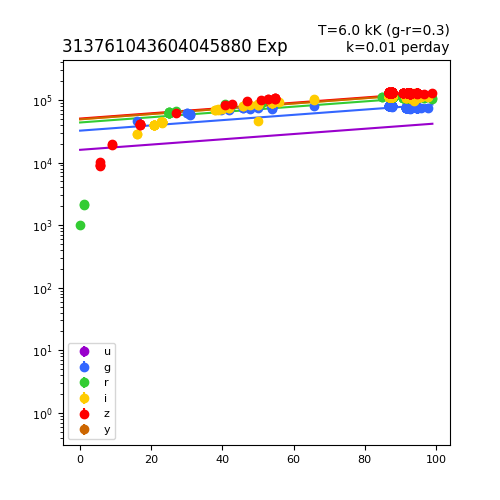

In [13]:
diaObjectId = 313928194477522960
diaObjectId = 313761043604045880
runBBB(diaObjectId)